In [38]:
#import
import pandas as pd

from sklearn.model_selection import train_test_split  #データの分割
from sklearn.preprocessing import StandardScaler  #標準化
from sklearn.covariance import MinCovDet  #マハラノビス距離


In [39]:
#データの前処理
df=pd.read_csv('sukkiri-ml-codes (1)\datafiles\Bank.csv')
df.head(5)


,id,age,job,marital,education,default,amount,housing,loan,contact,day,month,duration,campaign,previous,y
0,1,39,blue-collar,married,secondary,no,1756.0,yes,no,cellular,3,apr,370.055237,1,0,1
1,2,51,entrepreneur,married,primary,no,1443.0,no,no,cellular,18,feb,233.998933,10,0,1
2,3,36,management,single,tertiary,no,436.0,no,no,cellular,13,apr,NaN,1,2,0
3,4,63,retired,married,secondary,no,474.0,no,no,cellular,25,jan,252.525808,1,0,0
4,5,31,management,single,tertiary,no,354.0,no,no,cellular,30,apr,NaN,1,2,0


In [40]:
#ダミー変数化
str_col_name=['job','default','marital','education','housing','loan','contact','month']
str_df = df[str_col_name]  #文字列を抜き出す
str_df2=pd.get_dummies(str_df,drop_first=True)  #複数列を一気にダミー変数化

num_df = df.drop(str_col_name,axis=1)  #数値列を抜き出す
df2 = pd.concat([num_df,str_df2,],axis=1)  #結合


#不要な特徴量の削除
df2=df2.drop('id',axis=1)
df2=df2.dropna()


#訓練&検証データとテストデータに分割
train_val,test = train_test_split(df2,test_size=0.1,random_state=9)
train_val.head()

,age,amount,day,duration,campaign,previous,y,job_blue-collar,job_entrepreneur,job_housemaid,...,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep
22238,33,673.0,14,262.478505,2,0,0,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3399,40,60.0,25,223.051629,1,0,0,True,False,False,...,False,False,False,True,False,False,False,False,False,False
24619,37,3321.0,16,217.124395,3,0,1,False,False,False,...,False,False,False,False,True,False,False,False,False,False
26704,30,-256.0,15,306.013305,5,0,0,False,False,False,...,False,False,False,False,False,False,True,False,False,False
26709,61,1058.0,27,242.441425,2,3,0,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [41]:
print(df2.columns)
print()
print(df2.dtypes)

Index(['age', 'amount', 'day', 'duration', 'campaign', 'previous', 'y',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'default_yes', 'marital_married', 'marital_single',
       'education_secondary', 'education_tertiary', 'education_unknown',
       'housing_yes', 'loan_yes', 'contact_sending _document',
       'contact_telephone', 'month_aug', 'month_dec', 'month_feb', 'month_jan',
       'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov',
       'month_oct', 'month_sep'],
      dtype='object')

age                            int64
amount                       float64
day                            int64
duration                     float64
campaign                       int64
previous                       int64
y                              int64
job_blue-collar                 bool
job_entrepreneu

<Axes: >

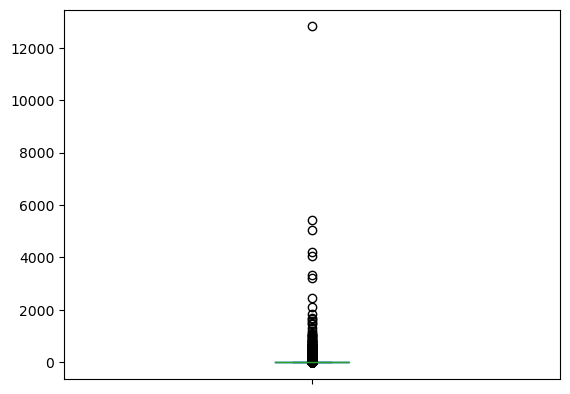

In [42]:
#マハラノビス距離を求める
#train_val全体でやるとLinAlgErrorになったので、今回はダミー変数を除く
mcd2 =MinCovDet(random_state=0,support_fraction=0.7)
num_train_val_name = ['age', 'amount', 'day', 'duration', 'campaign', 'previous', 'y'] #数値列を抜き出す
num_train_val=train_val[num_train_val_name]

mcd2.fit(num_train_val) 
dis = pd.Series(
    mcd2.mahalanobis(num_train_val),
    index=train_val.index
)
dis=pd.Series(dis)

#箱ひげ図を描く
dis.plot(kind="box")

In [43]:
no=dis[dis>12000].index
train_val2 = train_val.drop(no)

<Axes: >

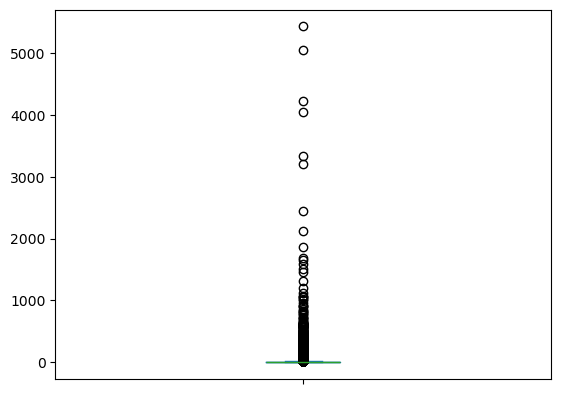

In [44]:
num_train_val2=train_val2[num_train_val_name]
mcd2.fit(num_train_val2) 
dis2 =mcd2.mahalanobis(num_train_val2)
dis2=pd.Series(dis2)
dis2.plot(kind="box")

In [45]:
print(no)
print(train_val.index)

Index([16312], dtype='int64')
Index([22238,  3399, 24619, 26704, 26709, 18820, 14794, 13648, 21696,  6507,
       ...
       15808,  8784, 24339, 14170,  5186,  6157,  6344,  6805, 13474,   691],
      dtype='int64', length=18075)


リッジ回帰

In [46]:
import 

SyntaxError: Expected one or more names after 'import' (2494350585.py, line 1)